In [1]:
import pandas as pd
import numpy as np

np.random.seed(42)

# Customers
customers = pd.DataFrame({
    'customer_id': range(1, 101),
    'signup_date': pd.date_range('2023-01-01', periods=100),
    'age': np.random.randint(18, 60, 100),
    'gender': np.random.choice(['Male', 'Female'], 100),
    'country': np.random.choice(['India', 'USA', 'UK'], 100),
    'plan_type': np.random.choice(['Basic', 'Premium'], 100),
    'monthly_fee': np.random.randint(200, 2000, 100)
})

# Transactions
transactions = pd.DataFrame({
    'customer_id': np.random.randint(1, 101, 300),
    'transaction_date': pd.date_range('2024-01-01', periods=300),
    'amount': np.random.randint(100, 5000, 300),
    'payment_method': np.random.choice(['Card', 'UPI', 'NetBanking'], 300),
    'is_refund': np.random.choice([0,1], 300, p=[0.9,0.1])
})

# Events
events = pd.DataFrame({
    'customer_id': np.random.randint(1,101,300),
    'event_date': pd.date_range('2024-01-01', periods=300),
    'event_type': np.random.choice(['Login','Purchase','View'],300),
    'event_value': np.random.randint(1,100,300)
})

# Support Tickets
support = pd.DataFrame({
    'ticket_id': range(1,101),
    'customer_id': np.random.randint(1,101,100),
    'ticket_date': pd.date_range('2024-01-01', periods=100),
    'ticket_category': np.random.choice(['Billing','Technical'],100),
    'resolution_time_hrs': np.random.randint(1,48,100),
    'satisfaction_score': np.random.randint(1,6,100)
})

# Churn Labels
churn = pd.DataFrame({
    'customer_id': range(1,101),
    'churn_30d': np.random.choice([0,1],100,p=[0.7,0.3])
})

# CLV Labels
clv = pd.DataFrame({
    'customer_id': range(1,101),
    'clv': np.random.randint(1000,50000,100)
})

customers.to_csv('customers.csv',index=False)
transactions.to_csv('transactions.csv',index=False)
events.to_csv('events.csv',index=False)
support.to_csv('support_tickets.csv',index=False)
churn.to_csv('churn_labels.csv',index=False)
clv.to_csv('clv_labels.csv',index=False)

print("All datasets created successfully!")

All datasets created successfully!


In [2]:
customers = pd.read_csv("customers.csv")
customers.head()

,customer_id,signup_date,age,gender,country,plan_type,monthly_fee
0,1,2023-01-01,56,Male,USA,Basic,765
1,2,2023-01-02,46,Female,India,Basic,769
2,3,2023-01-03,32,Female,India,Basic,1546
3,4,2023-01-04,25,Female,UK,Basic,885
4,5,2023-01-05,38,Male,USA,Premium,825


In [3]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   customer_id  100 non-null    int64 
 1   signup_date  100 non-null    object
 2   age          100 non-null    int64 
 3   gender       100 non-null    object
 4   country      100 non-null    object
 5   plan_type    100 non-null    object
 6   monthly_fee  100 non-null    int64 
dtypes: int64(3), object(4)
memory usage: 5.6+ KB


In [4]:
customers.isnull().sum()

,0
customer_id,0
signup_date,0
age,0
gender,0
country,0
plan_type,0
monthly_fee,0


In [5]:
customers.describe()

,customer_id,age,monthly_fee
count,100.000000,100.000000,100.000000
mean,50.500000,37.910000,1094.570000
std,29.011492,12.219454,479.087037
min,1.000000,18.000000,204.000000
25%,25.750000,26.750000,768.000000
50%,50.500000,38.000000,1059.500000
75%,75.250000,46.250000,1414.500000
max,100.000000,59.000000,1999.000000


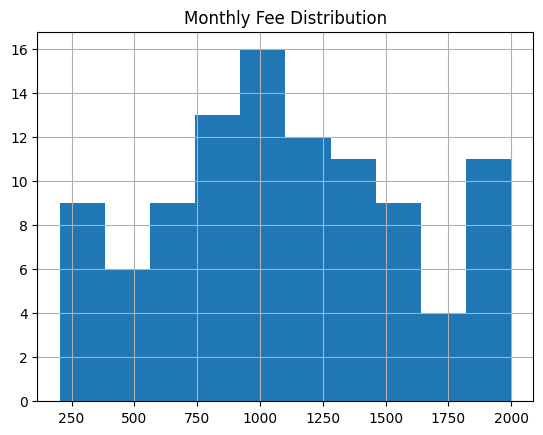

In [6]:
import matplotlib.pyplot as plt

customers['monthly_fee'].hist()
plt.title("Monthly Fee Distribution")
plt.show()

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

data = customers.merge(clv,on='customer_id')

X = data[['age','monthly_fee']]
y = data['clv']

X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.2,random_state=42
)

model = LinearRegression()
model.fit(X_train,y_train)

print("CLV Model Trained")


CLV Model Trained


In [8]:
from sklearn.linear_model import LogisticRegression

data2 = customers.merge(churn,on='customer_id')

X = data2[['age','monthly_fee']]
y = data2['churn_30d']

X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.2,random_state=42
)

model2 = LogisticRegression(max_iter=1000)
model2.fit(X_train,y_train)

print("Churn Model Trained")

Churn Model Trained


In [9]:
from sklearn.metrics import accuracy_score

pred = model2.predict(X_test)

print("Accuracy =", accuracy_score(y_test,pred))

Accuracy = 0.65
